Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


82/82 ━━━━━━━━━━━━━━━━━━━━ 103s 942ms/step - accuracy: 0.7499 - loss: 0.4858 - val_accuracy: 0.8125 - val_loss: 0.4998 - learning_rate: 1.0000e-04
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 68s 758ms/step - accuracy: 0.9026 - loss: 0.2319 - val_accuracy: 0.8125 - val_loss: 0.3486 - learning_rate: 1.0000e-04
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 69s 766ms/step - accuracy: 0.9286 - loss: 0.1848 - val_accuracy: 0.8125 - val_loss: 0.6174 - learning_rate: 1.0000e-04
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 70s 774ms/step - accuracy: 0.9402 - loss: 0.1688 - val_accuracy: 0.8750 - val_loss: 0.3110 - learning_rate: 1.0000e-04
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 69s 771ms/step - accuracy: 0.9427 - loss: 0.1494 - val_accuracy: 0.8125 - val_loss: 0.4023 - learning_rate: 1.0000e-04
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 69s 763ms/step - accuracy: 0.9515 - loss: 0.1307 - val_accuracy: 0.8125 - val_loss: 0.2838 - learning_rate: 1.0000e-04
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 68s 759ms/step - accuracy: 0.9

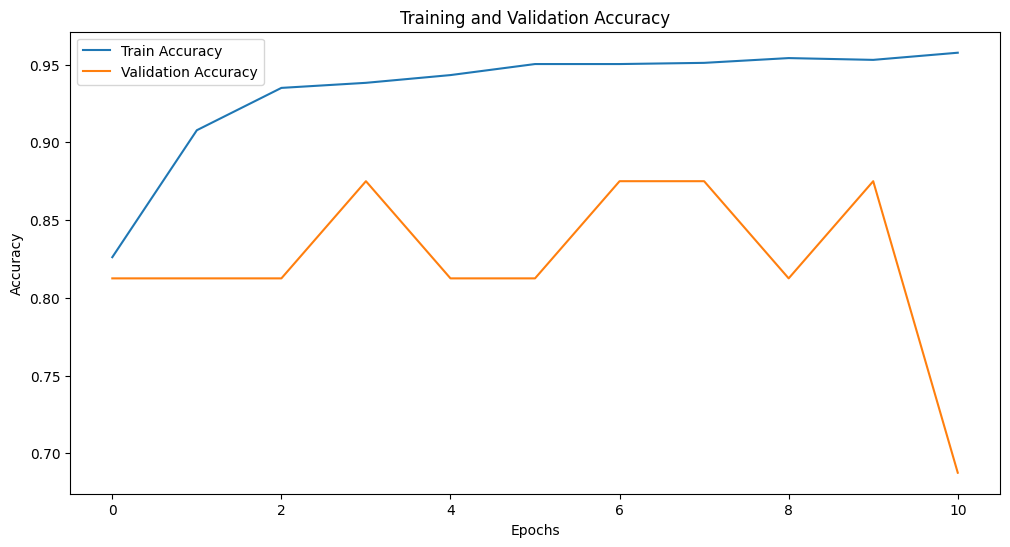

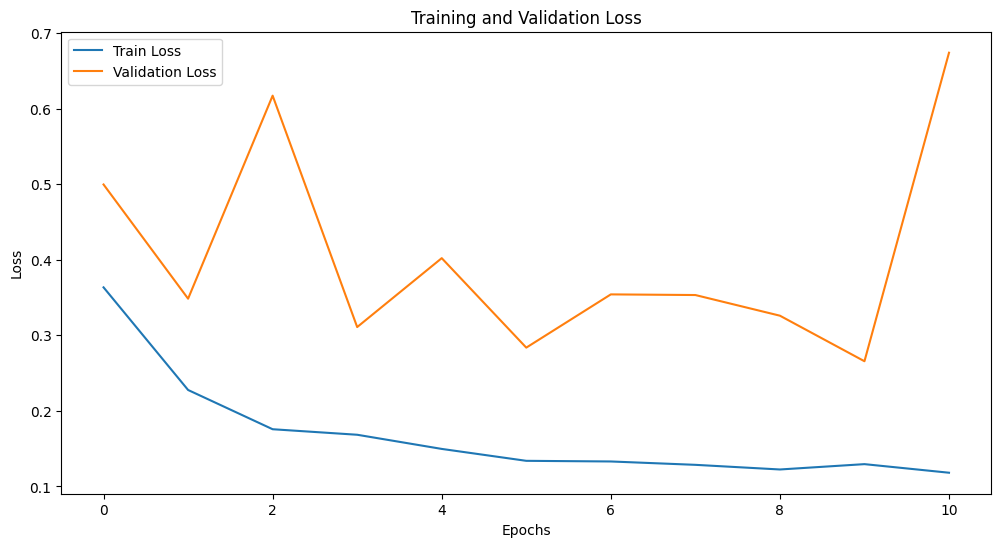

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 206ms/step - accuracy: 0.9103 - loss: 0.2671

Best Model Test Accuracy: 92.15%
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step


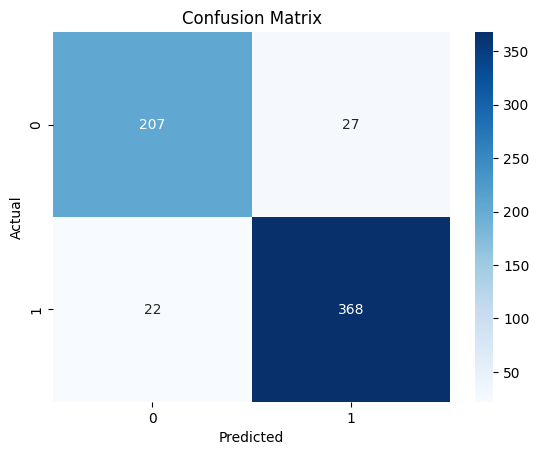

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.90      0.88      0.89       234
   PNEUMONIA       0.93      0.94      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.91      0.92       624
weighted avg       0.92      0.92      0.92       624

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step


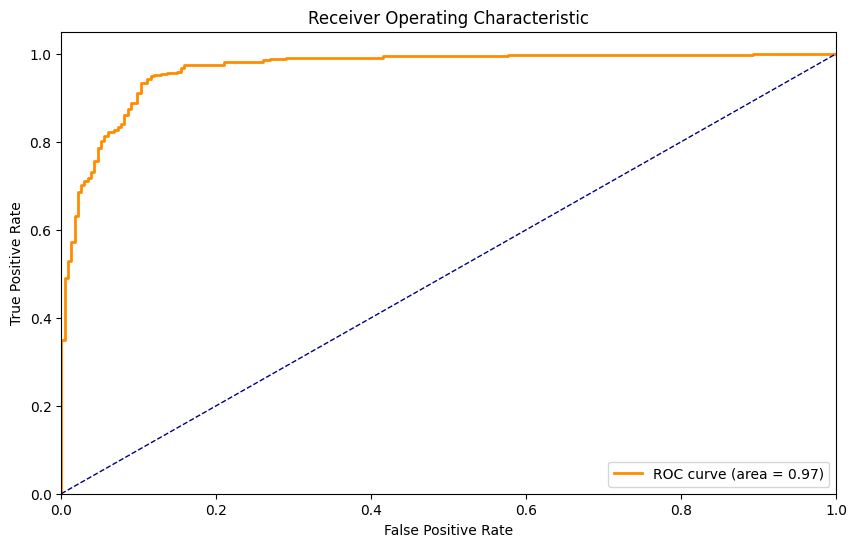

In [4]:
#VGG16
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import os

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Data Preparation
base_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/'
train_dir = base_dir + 'train/'
val_dir = base_dir + 'val/'
test_dir = base_dir + 'test/'

# Image Data Augmentation for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Data Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# Build VGG16 Model for Pneumonia Detection
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze base model layers
base_model.trainable = True
for layer in base_model.layers[:15]:
    layer.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.6)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile the Model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Model Checkpoint and Early Stopping
checkpoint_path = "best_vgg16_model.keras"
from tensorflow.keras.callbacks import LearningRateScheduler

def lr_schedule(epoch, lr):
    if epoch > 10:
        lr *= 0.5
    return lr

callbacks = [LearningRateScheduler(lr_schedule),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# Train the Model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks
)

# Save the Trained Model
model_save_path = "pneumonia_detection_vgg16_model.h5"
model.save(model_save_path)
print(f"Model saved at: {model_save_path}")

# Plotting Training and Validation Accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plotting Training and Validation Loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluation on Test Data
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Load the Best Model
best_model = load_model(checkpoint_path)
eval_results = best_model.evaluate(test_generator)
print(f"\nBest Model Test Accuracy: {eval_results[1] * 100:.2f}%")

# Confusion Matrix and Classification Report
predictions = (best_model.predict(test_generator) > 0.5).astype('int32')
true_classes = test_generator.classes

conf_matrix = confusion_matrix(true_classes, predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report:")
print(classification_report(true_classes, predictions, target_names=test_generator.class_indices.keys()))

# ROC-AUC Curve
pred_probs = best_model.predict(test_generator).ravel()
roc_auc = roc_auc_score(true_classes, pred_probs)

fpr, tpr, thresholds = roc_curve(true_classes, pred_probs)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


82/82 ━━━━━━━━━━━━━━━━━━━━ 116s 994ms/step - accuracy: 0.7321 - loss: 0.4477 - val_accuracy: 0.6250 - val_loss: 1.0143 - learning_rate: 1.0000e-04
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 71s 793ms/step - accuracy: 0.9315 - loss: 0.2193 - val_accuracy: 0.8750 - val_loss: 0.3795 - learning_rate: 1.0000e-04
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 69s 767ms/step - accuracy: 0.9402 - loss: 0.1596 - val_accuracy: 0.8750 - val_loss: 0.2096 - learning_rate: 1.0000e-04
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 70s 782ms/step - accuracy: 0.9522 - loss: 0.1286 - val_accuracy: 0.9375 - val_loss: 0.2357 - learning_rate: 1.0000e-04
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 69s 768ms/step - accuracy: 0.9598 - loss: 0.1050 - val_accuracy: 0.8750 - val_loss: 0.2189 - learning_rate: 1.0000e-04
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 69s 767ms/step - accuracy: 0.9593 - loss: 0.1081 - val_accuracy: 0.8750 - val_loss: 0.2643 - learning_rate: 1.0000e-04
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 68s 761ms/step - accuracy: 0.9

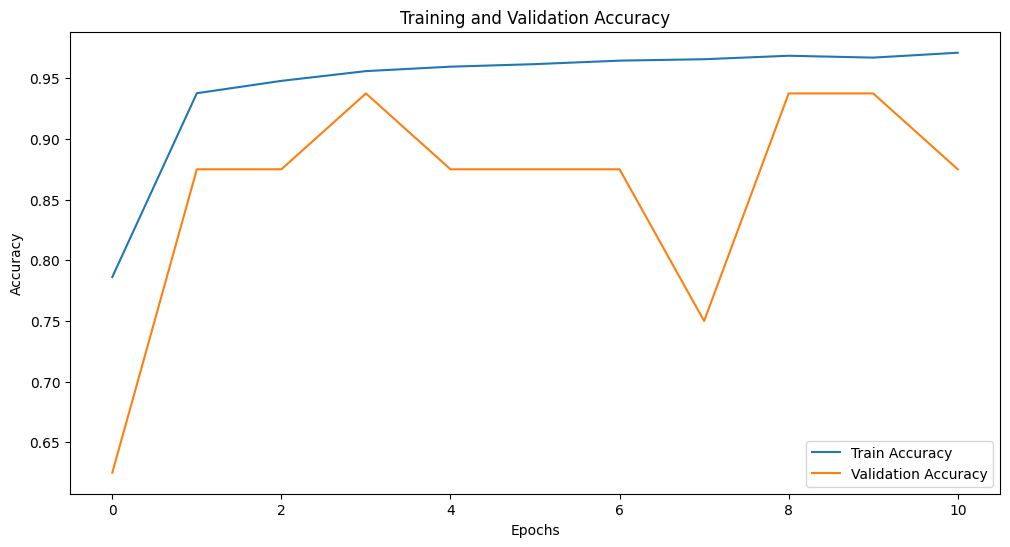

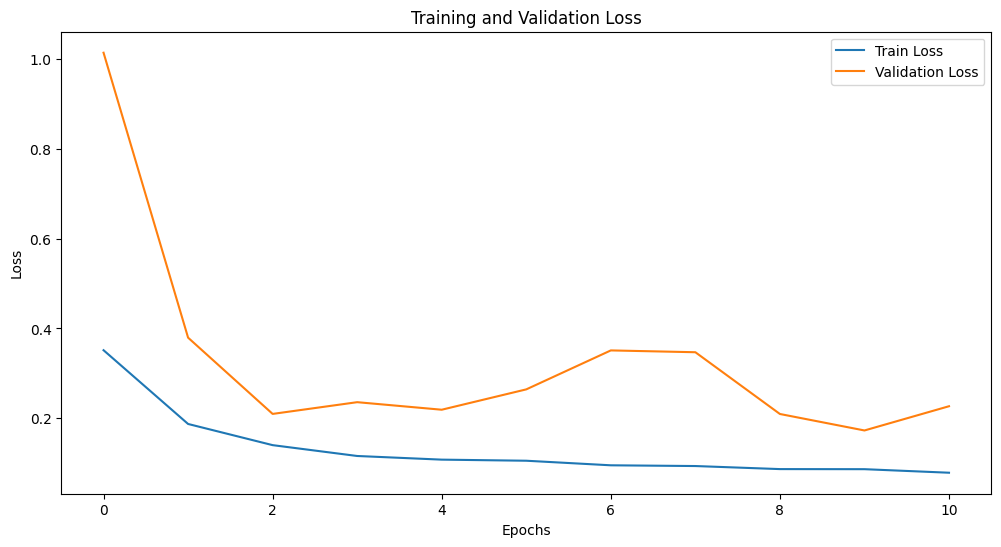

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - accuracy: 0.9287 - loss: 0.1873

Best Model Test Accuracy: 92.31%
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 294ms/step


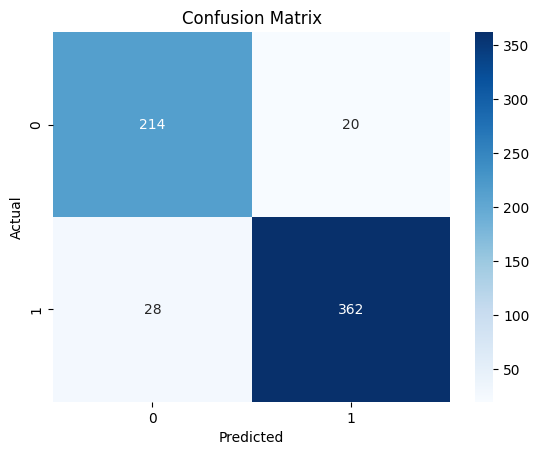

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.88      0.91      0.90       234
   PNEUMONIA       0.95      0.93      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.92      0.92       624
weighted avg       0.92      0.92      0.92       624

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step


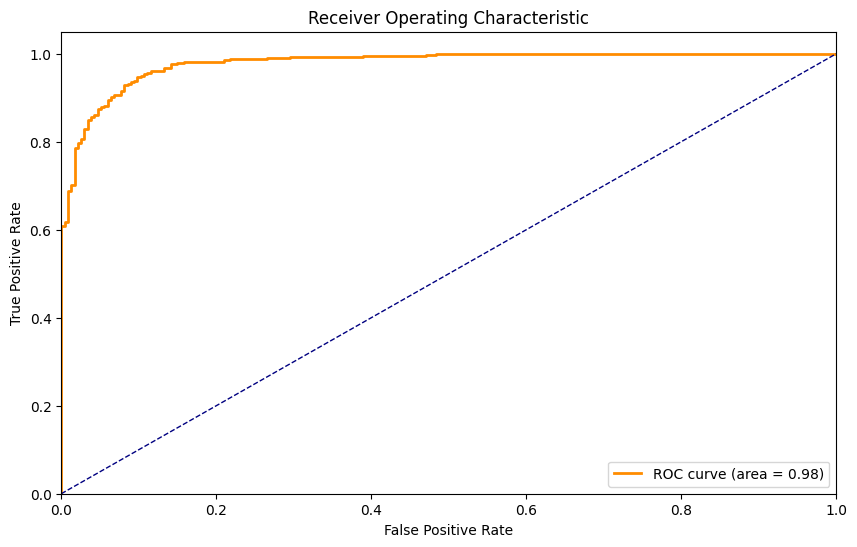

In [5]:
#Xception
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import Xception
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import os

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Data Preparation
base_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/'
train_dir = base_dir + 'train/'
val_dir = base_dir + 'val/'
test_dir = base_dir + 'test/'

# Image Data Augmentation for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Data Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# Build Xception Model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze base model layers
base_model.trainable = True
for layer in base_model.layers[:80]:
    layer.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.6)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile the Model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Model Checkpoint and Early Stopping
checkpoint_path = "best_xception_model_v2.keras"
from tensorflow.keras.callbacks import LearningRateScheduler

def lr_schedule(epoch, lr):
    if epoch > 10:
        lr *= 0.5
    return lr

callbacks = [LearningRateScheduler(lr_schedule),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# Train the Model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks
)

# Save the Trained Model
model_save_path = "pneumonia_detection_xception_model.h5"
model.save(model_save_path)
print(f"Model saved at: {model_save_path}")

# Plotting Training and Validation Accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plotting Training and Validation Loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluation on Test Data
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Load the Best Model
best_model = load_model(checkpoint_path)
eval_results = best_model.evaluate(test_generator)
print(f"\nBest Model Test Accuracy: {eval_results[1] * 100:.2f}%")

# Confusion Matrix and Classification Report
predictions = (best_model.predict(test_generator) > 0.5).astype('int32')
true_classes = test_generator.classes

conf_matrix = confusion_matrix(true_classes, predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report:")
print(classification_report(true_classes, predictions, target_names=test_generator.class_indices.keys()))

# ROC-AUC Curve
pred_probs = best_model.predict(test_generator).ravel()
roc_auc = roc_auc_score(true_classes, pred_probs)

fpr, tpr, thresholds = roc_curve(true_classes, pred_probs)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


82/82 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.7723 - loss: 0.4785 - val_accuracy: 0.5000 - val_loss: 0.8828 - learning_rate: 1.0000e-04
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 70s 784ms/step - accuracy: 0.8538 - loss: 0.3217 - val_accuracy: 0.5000 - val_loss: 5.7056 - learning_rate: 1.0000e-04
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 69s 771ms/step - accuracy: 0.8650 - loss: 0.2997 - val_accuracy: 0.5000 - val_loss: 14.5364 - learning_rate: 1.0000e-04
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 69s 773ms/step - accuracy: 0.9005 - loss: 0.2480 - val_accuracy: 0.5000 - val_loss: 5.9685 - learning_rate: 1.0000e-04
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 69s 764ms/step - accuracy: 0.9049 - loss: 0.2303 - val_accuracy: 0.5000 - val_loss: 5.8144 - learning_rate: 1.0000e-04
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 72s 801ms/step - accuracy: 0.9136 - loss: 0.2091 - val_accuracy: 0.5625 - val_loss: 2.4286 - learning_rate: 1.0000e-04
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 70s 772ms/step - accuracy: 0.929

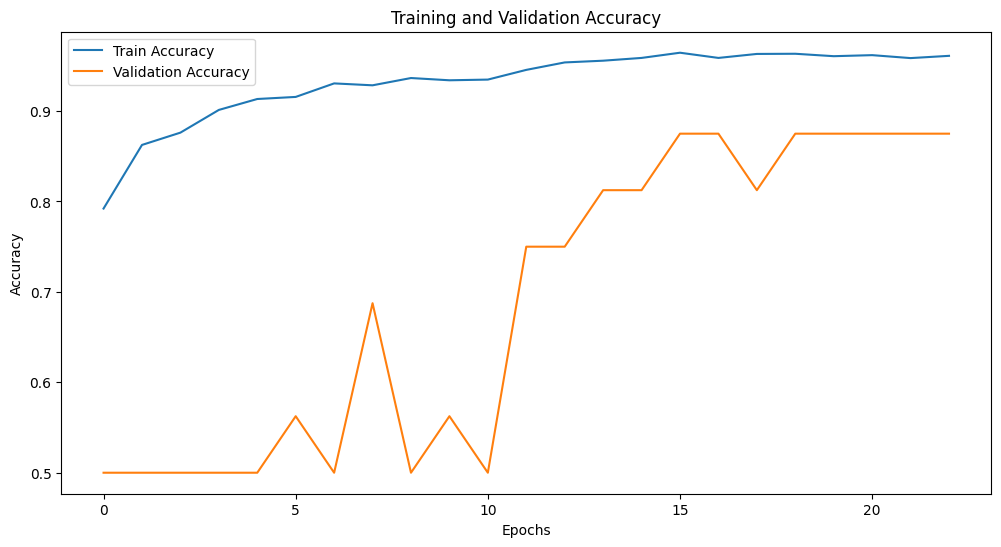

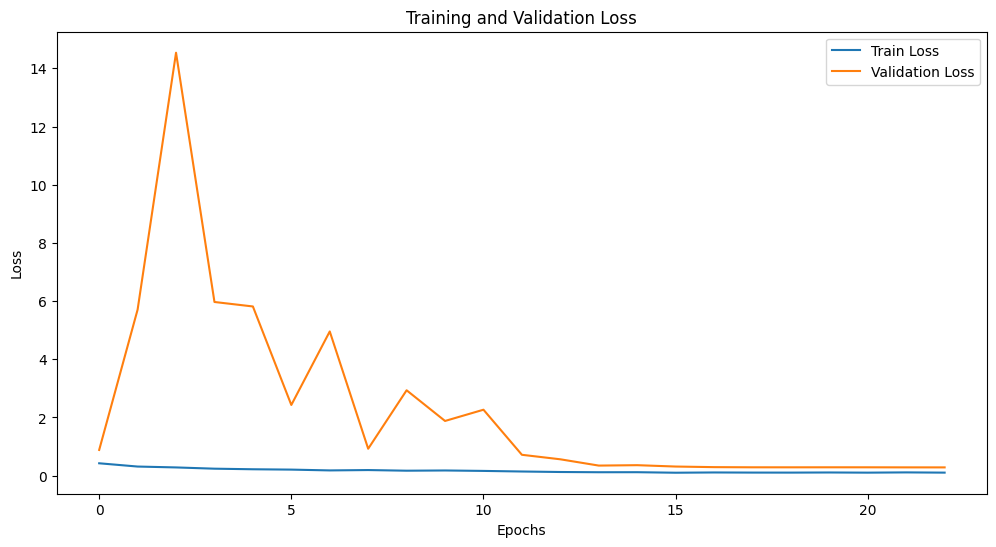

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 248ms/step - accuracy: 0.9142 - loss: 0.2239

Best Model Test Accuracy: 93.59%
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 338ms/step


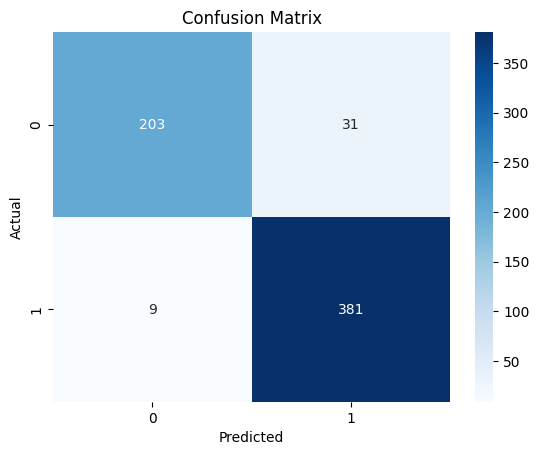

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.87      0.91       234
   PNEUMONIA       0.92      0.98      0.95       390

    accuracy                           0.94       624
   macro avg       0.94      0.92      0.93       624
weighted avg       0.94      0.94      0.94       624

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step


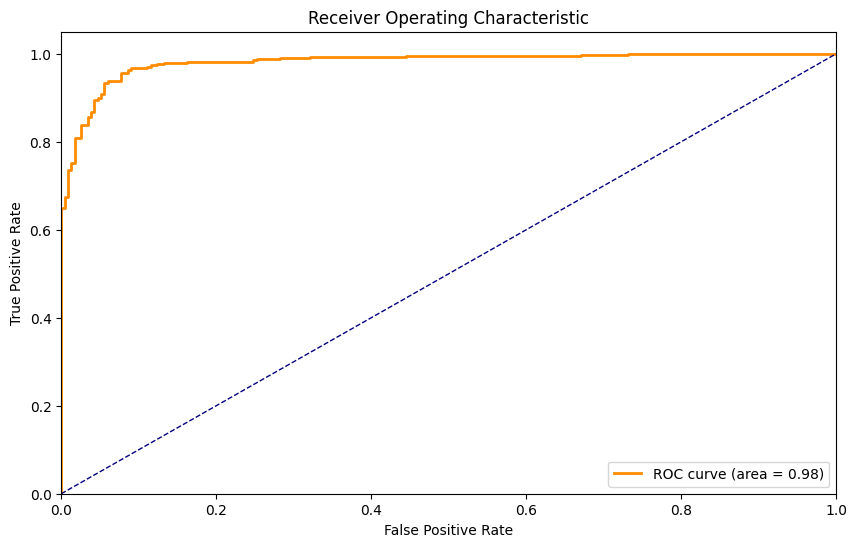

In [3]:
#ResNet50
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import os

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Data Preparation
base_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/'
train_dir = base_dir + 'train/'
val_dir = base_dir + 'val/'
test_dir = base_dir + 'test/'

# Image Data Augmentation for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Data Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# Build ResNet50 Model for Pneumonia Detection
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze base model layers
base_model.trainable = True
for layer in base_model.layers[:50]:
    layer.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.6)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile the Model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Model Checkpoint and Early Stopping
checkpoint_path = "best_resnet50_model.keras"
from tensorflow.keras.callbacks import LearningRateScheduler

def lr_schedule(epoch, lr):
    if epoch > 10:
        lr *= 0.5
    return lr

callbacks = [LearningRateScheduler(lr_schedule),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# Train the Model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks
)

# Save the Trained Model
model_save_path = "pneumonia_detection_resnet50_model.h5"
model.save(model_save_path)
print(f"Model saved at: {model_save_path}")

# Plotting Training and Validation Accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plotting Training and Validation Loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluation on Test Data
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Load the Best Model
best_model = load_model(checkpoint_path)
eval_results = best_model.evaluate(test_generator)
print(f"\nBest Model Test Accuracy: {eval_results[1] * 100:.2f}%")

# Confusion Matrix and Classification Report
predictions = (best_model.predict(test_generator) > 0.5).astype('int32')
true_classes = test_generator.classes

conf_matrix = confusion_matrix(true_classes, predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report:")
print(classification_report(true_classes, predictions, target_names=test_generator.class_indices.keys()))

# ROC-AUC Curve
pred_probs = best_model.predict(test_generator).ravel()
roc_auc = roc_auc_score(true_classes, pred_probs)

fpr, tpr, thresholds = roc_curve(true_classes, pred_probs)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


163/163 ━━━━━━━━━━━━━━━━━━━━ 203s 534ms/step - accuracy: 0.7985 - loss: 14.8466 - val_accuracy: 0.8125 - val_loss: 9.9074 - learning_rate: 1.0000e-04
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 445ms/step - accuracy: 0.9308 - loss: 8.0055 - val_accuracy: 0.6875 - val_loss: 5.5868 - learning_rate: 1.0000e-04
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 449ms/step - accuracy: 0.9537 - loss: 4.1356 - val_accuracy: 0.8125 - val_loss: 2.8780 - learning_rate: 1.0000e-04
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 448ms/step - accuracy: 0.9561 - loss: 2.1056 - val_accuracy: 0.6875 - val_loss: 2.0057 - learning_rate: 1.0000e-04
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 80s 470ms/step - accuracy: 0.9641 - loss: 1.0929 - val_accuracy: 0.8750 - val_loss: 0.9134 - learning_rate: 1.0000e-04
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 442ms/step - accuracy: 0.9644 - loss: 0.6133 - val_accuracy: 0.8750 - val_loss: 0.7142 - learning_rate: 1.0000e-04
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 446ms/step 

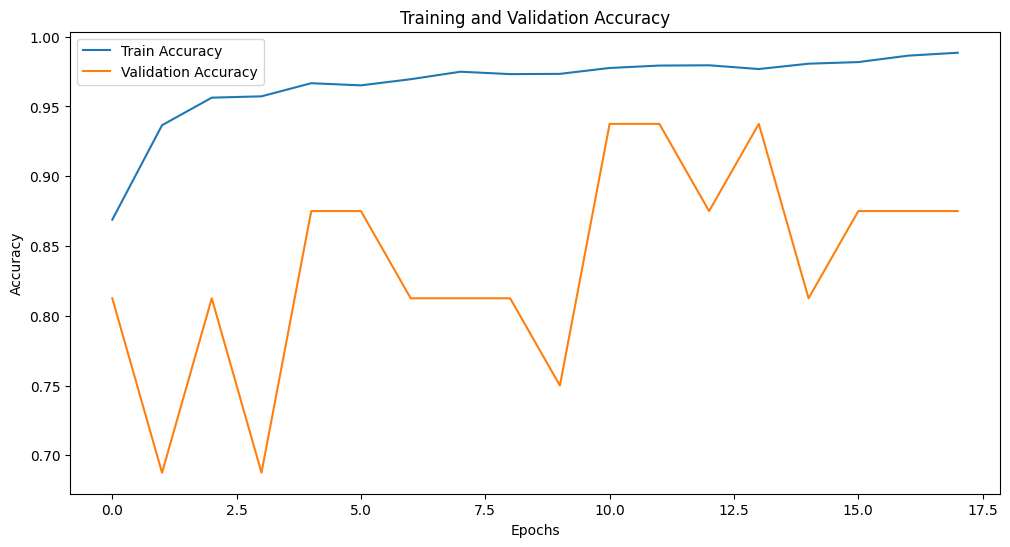

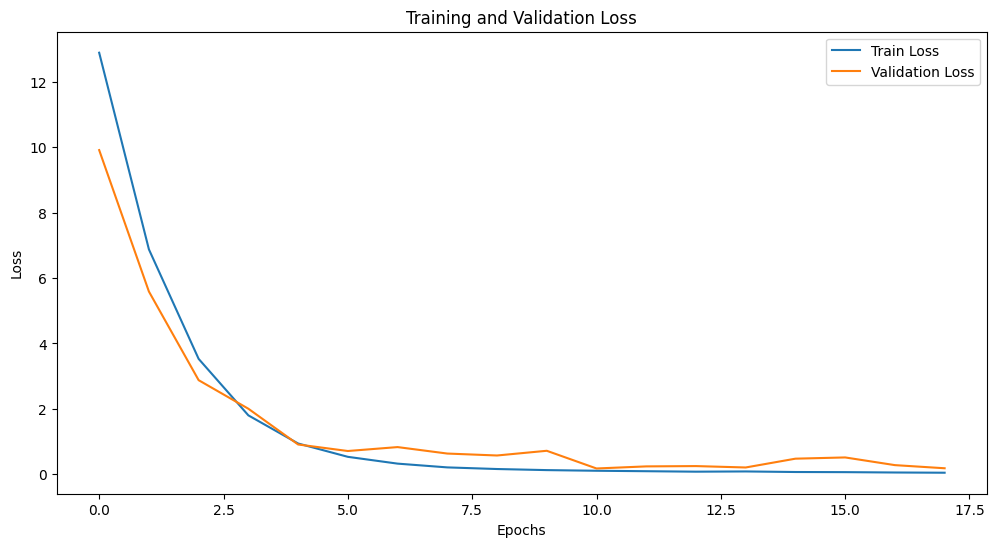

624/624 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.9181 - loss: 0.2539

✅ Best Model Test Accuracy: 92.47%
624/624 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step


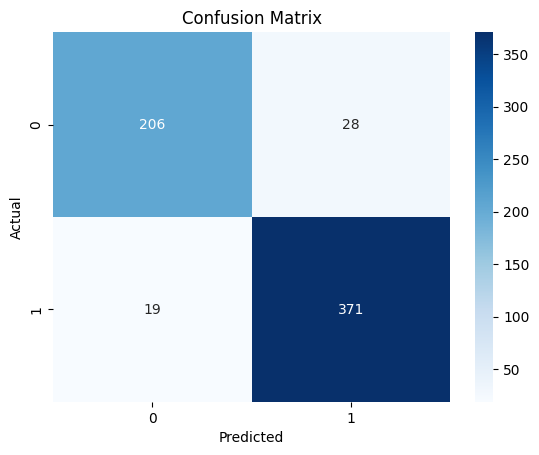

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       234
           1       0.93      0.95      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.92      0.92       624
weighted avg       0.92      0.92      0.92       624

624/624 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step


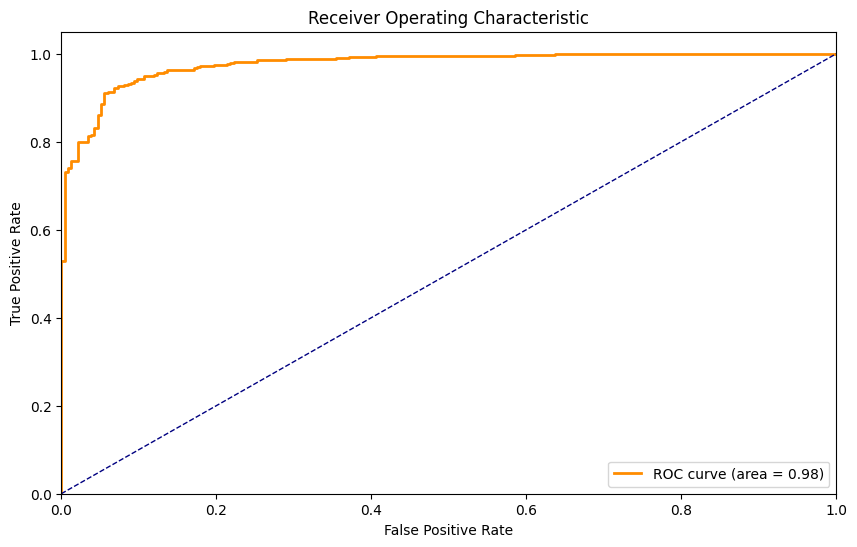

In [2]:
#InceptionResNetV2
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# **Dataset Paths**
dataset_path = "/kaggle/input/chest-xray-pneumonia/chest_xray"
train_dir = os.path.join(dataset_path, 'train')
val_dir = os.path.join(dataset_path, 'val')
test_dir = os.path.join(dataset_path, 'test')

# **Improved Data Augmentation**
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32, class_mode='binary'
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=(150, 150), batch_size=32, class_mode='binary'
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=(150, 150), batch_size=1, class_mode='binary', shuffle=False
)

# **Load InceptionResNetV2 & Fine-Tune More Layers**
base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# **Unfreeze Last 100 Layers (Instead of 250) for Better Fine-Tuning**
base_model.trainable = True
for layer in base_model.layers[:200]:  
    layer.trainable = False  

# **Custom Classification Head**
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.6)(x)
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# **Compile with Adaptive Learning Rate**
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# **Callbacks for Better Training Stability**
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint(filepath="best_inception_resnet_model.keras", monitor='val_accuracy', save_best_only=True)
]

# **Train the Model**
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks
)

# **Save the Model**
model.save("pneumonia_detection_inception_resnet_model.h5")
print("Model saved successfully!")

# **Plot Accuracy & Loss Curves**
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# **Evaluate on Test Data**
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\n✅ Best Model Test Accuracy: {test_accuracy * 100:.2f}%")

# **Confusion Matrix & Classification Report**
predictions = (model.predict(test_generator) > 0.5).astype('int32')
true_classes = test_generator.classes

conf_matrix = confusion_matrix(true_classes, predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report:")
print(classification_report(true_classes, predictions))

# **ROC-AUC Curve**
pred_probs = model.predict(test_generator).ravel()
roc_auc = roc_auc_score(true_classes, pred_probs)
fpr, tpr, thresholds = roc_curve(true_classes, pred_probs)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


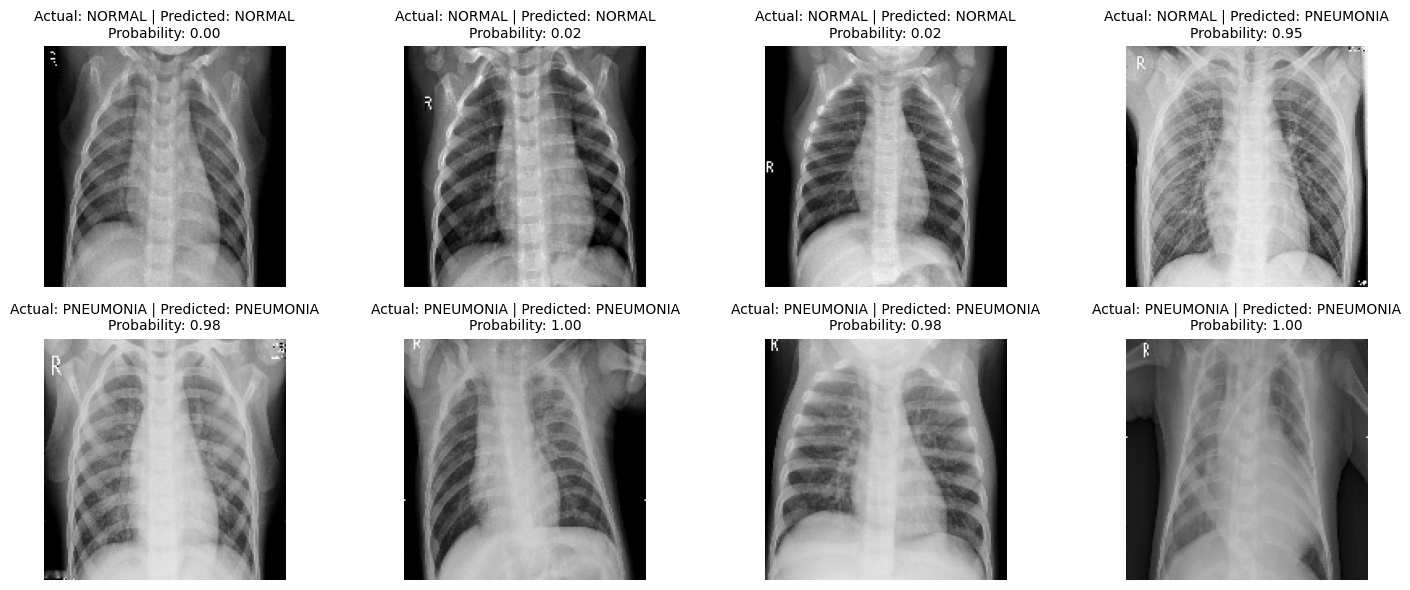

In [15]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os

# Load the trained model
model_path = "best_inception_resnet_model.keras"  # Ensure correct model path
model = tf.keras.models.load_model(model_path)

# Function to predict an image and return result and probability
def predict_image(img_path, model):
    img = image.load_img(img_path, target_size=(150, 150))  # Resize
    img_array = image.img_to_array(img)  # Convert to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.0  # Normalize

    probability = model.predict(img_array)[0][0]  # Predict
    predicted_class = "PNEUMONIA" if probability > 0.5 else "NORMAL"

    return predicted_class, probability

# Set test image directories (update with actual paths)
normal_images_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL'
pneumonia_images_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA'

# Collect 5 images for each class
normal_images = [os.path.join(normal_images_dir, img) for img in os.listdir(normal_images_dir)][:4]
pneumonia_images = [os.path.join(pneumonia_images_dir, img) for img in os.listdir(pneumonia_images_dir)][:4]

# Create a 2-row, 5-column grid for displaying results
fig, axes = plt.subplots(2, 4, figsize=(15, 6))  # Horizontal layout (2 rows x 5 columns)

# Plot NORMAL images (1st row)
for i, img_path in enumerate(normal_images):
    predicted_label, probability = predict_image(img_path, model)
    
    ax = axes[0, i]
    img = image.load_img(img_path, target_size=(150, 150))
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    
    actual_label = "NORMAL"
    ax.set_title(f"Actual: {actual_label} | Predicted: {predicted_label}\nProbability: {probability:.2f}", fontsize=10)

# Plot PNEUMONIA images (2nd row)
for i, img_path in enumerate(pneumonia_images):
    predicted_label, probability = predict_image(img_path, model)
    
    ax = axes[1, i]
    img = image.load_img(img_path, target_size=(150, 150))
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    
    actual_label = "PNEUMONIA"
    ax.set_title(f"Actual: {actual_label} | Predicted: {predicted_label}\nProbability: {probability:.2f}", fontsize=10)

plt.tight_layout()
plt.show()
